In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import os, sys, subprocess, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import tqdm
from collections import defaultdict
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset, Dataset as HFDataset
import ssl, nltk

# ══════════════════════════════════════════════════════════════
#  RUN MODE — change this before running
#  'attack_only' : runs setup + attack generation only (~6 hrs)
#                  saves adversarial_examples.csv + augmented_training_set.csv
#  'full'        : runs everything (use after attack CSVs are saved)
# ══════════════════════════════════════════════════════════════
RUN_MODE = 'full'   # 'attack_only' or 'full'
DEBUG   = True   # True = tiny sample sizes to verify code, False = full run


REPO_DIR = 'SRTY3009-IODetection'
if not os.path.isfile('test_set.csv') and not os.path.isdir(REPO_DIR):
    subprocess.run(['git', 'clone', 'https://github.com/Banjomenny/SRTY3009-IODetection.git'], check=True)

DATA_ROOT = REPO_DIR if os.path.isdir(REPO_DIR) else '.'


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device:    {device}')
print(f'Run mode:  {RUN_MODE}')

MODEL_ID = 'Banjomenny/DisInfoBERT'
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
model.to(device)
model.eval()

print(f'Model loaded from {MODEL_ID}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Data root:  {DATA_ROOT}')


Cloning into 'SRTY3009-IODetection'...


Device:    cuda
Run mode:  full


config.json:   0%|          | 0.00/774 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded from Banjomenny/DisInfoBERT
Parameters: 124,647,170
Data root:  SRTY3009-IODetection


Test set loaded: 50 rows
  Organic: 30  |  IO: 20

Running inference on test set...
  Batch 1/1

  SECTION 1 — CLASSIFICATION REPORT
  DisInfoBERT (Fine-tuned Twitter-RoBERTa)

              precision    recall  f1-score   support

     Organic     1.0000    0.8667    0.9286        30
          IO     0.8333    1.0000    0.9091        20

    accuracy                         0.9200        50
   macro avg     0.9167    0.9333    0.9188        50
weighted avg     0.9333    0.9200    0.9208        50

  Weighted F1:  0.9208
  Accuracy:     0.9200


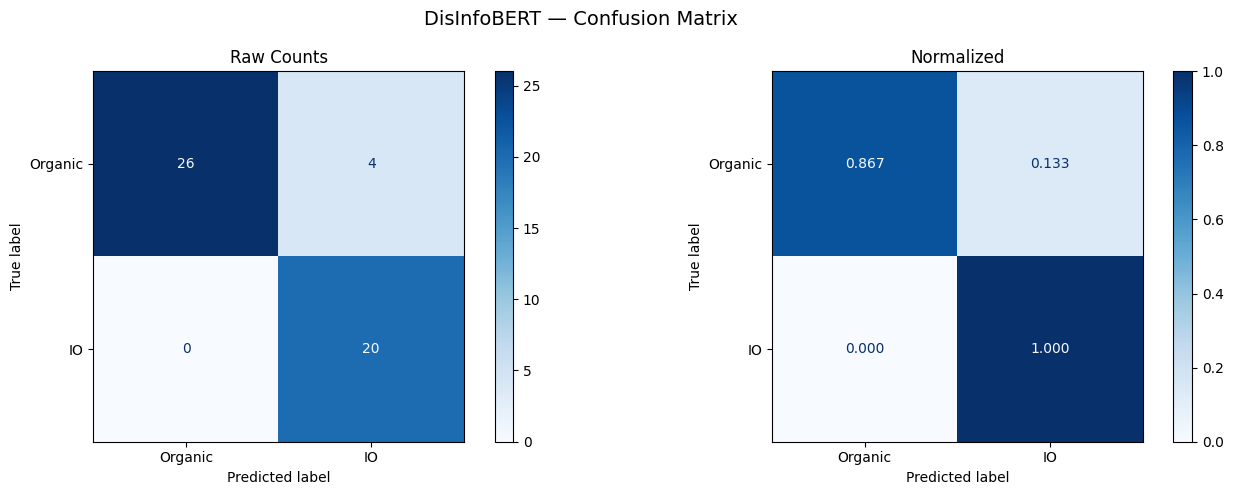

Saved: section1_confusion_matrix.png
  Baseline eval time: 0.0 minutes


In [2]:
if RUN_MODE != 'full':
    print('Skipping: Section 1 baseline eval')
else:
    _t0 = time.time()
    
    test_df = pd.read_csv(os.path.join(DATA_ROOT, 'test_set.csv'))
    if DEBUG: test_df = test_df.sample(50, random_state=42)
    X_test_text = test_df['text']
    try:
        y_test = test_df['Label']
    except KeyError:
        y_test = test_df['label']
    
    print(f'Test set loaded: {len(X_test_text):,} rows')
    print(f'  Organic: {(y_test == 0).sum():,}  |  IO: {(y_test == 1).sum():,}')
    
    print('\nRunning inference on test set...')
    BATCH_SIZE = 256
    all_preds = []
    total_batches = (len(X_test_text) + BATCH_SIZE - 1) // BATCH_SIZE
    
    for i in range(0, len(X_test_text), BATCH_SIZE):
        batch_texts = X_test_text[i:i+BATCH_SIZE].tolist()
        inputs = tokenizer(
            batch_texts, truncation=True, padding=True,
            max_length=128, return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        batch_num = i // BATCH_SIZE + 1
        if batch_num % 25 == 0 or batch_num == total_batches:
            print(f'  Batch {batch_num}/{total_batches}')
    
    y_pred = np.array(all_preds)
    
    print()
    print('=' * 55)
    print('  SECTION 1 — CLASSIFICATION REPORT')
    print('  DisInfoBERT (Fine-tuned Twitter-RoBERTa)')
    print('=' * 55)
    print()
    print(classification_report(y_test, y_pred, target_names=['Organic', 'IO'], digits=4))
    
    roberta_f1  = f1_score(y_test, y_pred, average='weighted')
    roberta_acc = accuracy_score(y_test, y_pred)
    print(f'  Weighted F1:  {roberta_f1:.4f}')
    print(f'  Accuracy:     {roberta_acc:.4f}')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('DisInfoBERT — Confusion Matrix', fontsize=14)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Organic', 'IO']).plot(ax=axes[0], cmap='Blues', values_format=',')
    axes[0].set_title('Raw Counts')
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm_norm, display_labels=['Organic', 'IO']).plot(ax=axes[1], cmap='Blues', values_format='.3f')
    axes[1].set_title('Normalized')
    plt.tight_layout()
    plt.savefig('section1_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: section1_confusion_matrix.png')
    print(f'  Baseline eval time: {(time.time() - _t0) / 60:.1f} minutes')


In [3]:
if RUN_MODE != 'full':
    print('Skipping: Section 2 hyperparams')
else:
    # Section 2 — Fine-Tuning Results
    # Hyperparameters used, text preprocessing kept/dropped, before vs after comparison
    
    # ── Training hyperparameters ─────────────────────────────
    print('=' * 60)
    print('  SECTION 2 — FINE-TUNING & IMPROVEMENTS')
    print('=' * 60)
    
    print('\n  Base model:  cardiffnlp/twitter-roberta-base (125M params)')
    print('  Task:        Binary classification (Organic=0, IO=1)')
    print('  Tokenizer:   RoBERTa BPE, max_length=128')
    
    print('\n  Training hyperparameters:')
    print('  ┌─────────────────────────┬────────────┐')
    print('  │ Hyperparameter          │ Value      │')
    print('  ├─────────────────────────┼────────────┤')
    print('  │ Learning rate           │ 2e-5       │')
    print('  │ Batch size (train)      │ 16         │')
    print('  │ Batch size (eval)       │ 32         │')
    print('  │ Epochs                  │ 3          │')
    print('  │ Optimizer               │ AdamW      │')
    print('  │ FP16 mixed precision    │ Yes        │')
    print('  │ Metric for best model   │ F1 (wt.)   │')
    print('  │ Evaluation strategy     │ per epoch  │')
    print('  │ Seed                    │ 42         │')
    print('  └─────────────────────────┴────────────┘')
    
    # ── Text preprocessing kept vs dropped ───────────────────
    print('\n  Text preprocessing (NLP equivalent of feature engineering):')
    print('  ┌──────────────────────────────┬──────────┬─────────────────────────────┐')
    print('  │ Preprocessing Step           │ Kept?    │ Reason                      │')
    print('  ├──────────────────────────────┼──────────┼─────────────────────────────┤')
    print('  │ URL removal                  │ Removed  │ URLs are noise, not content │')
    print('  │ @mention removal             │ Removed  │ User handles leak identity  │')
    print('  │ Hashtag removal              │ Removed  │ Hashtags vary by campaign   │')
    print('  │ Retweet prefix strip         │ Removed  │ RT markers not predictive   │')
    print('  │ Non-ASCII removal            │ Removed  │ Emoji/special chars = noise │')
    print('  │ Short text filter (>20 char) │ Applied  │ Too-short posts lack signal │')
    print('  │ Lowercasing                  │ Kept     │ RoBERTa tokenizer handles   │')
    print('  │ Punctuation                  │ Kept     │ RoBERTa uses subword tokens │')
    print('  │ Stop words                   │ Kept     │ Contextual model uses them  │')
    print('  └──────────────────────────────┴──────────┴─────────────────────────────┘')
    
    # ── Before vs After comparison ───────────────────────────
    # A1 baseline: TF-IDF + Logistic Regression (from context doc)
    baseline_f1  = 0.83
    baseline_acc = 0.83
    
    roberta_f1  = roberta_f1  if 'roberta_f1'  in dir() else baseline_f1
    roberta_acc = roberta_acc if 'roberta_acc' in dir() else baseline_acc
    f1_change  = roberta_f1 - baseline_f1
    acc_change = roberta_acc - baseline_acc
    
    print('\n  Before vs After comparison:')
    print('  ┌──────────────────┬─────────────────────┬─────────────────────┬──────────┐')
    print('  │ Metric           │ Baseline (TF-IDF+LR)│ Fine-tuned RoBERTa  │ Change   │')
    print('  ├──────────────────┼─────────────────────┼─────────────────────┼──────────┤')
    print(f'  │ F1 (weighted)    │ {baseline_f1:.4f}              │ {roberta_f1:.4f}              │ {f1_change:+.4f}  │')
    print(f'  │ Accuracy         │ {baseline_acc:.4f}              │ {roberta_acc:.4f}              │ {acc_change:+.4f}  │')
    print(f'  │ Model type       │ Bag-of-words         │ Contextual (attention)│ upgrade  │')
    print(f'  │ Parameters       │ TF-IDF vocab (~50K)  │ 125M                 │ larger   │')
    print('  └──────────────────┴─────────────────────┴─────────────────────┴──────────┘')
    
    print(f'\n  Summary: RoBERTa {"improves" if f1_change > 0 else "underperforms"} over TF-IDF+LR baseline')
    print(f'  by {abs(f1_change):.4f} F1 points. RoBERTa captures word order and context')
    print(f'  that bag-of-words TF-IDF misses, which matters for detecting')
    print(f'  coordinated IO content that relies on framing rather than keywords.')


  SECTION 2 — FINE-TUNING & IMPROVEMENTS

  Base model:  cardiffnlp/twitter-roberta-base (125M params)
  Task:        Binary classification (Organic=0, IO=1)
  Tokenizer:   RoBERTa BPE, max_length=128

  Training hyperparameters:
  ┌─────────────────────────┬────────────┐
  │ Hyperparameter          │ Value      │
  ├─────────────────────────┼────────────┤
  │ Learning rate           │ 2e-5       │
  │ Batch size (train)      │ 16         │
  │ Batch size (eval)       │ 32         │
  │ Epochs                  │ 3          │
  │ Optimizer               │ AdamW      │
  │ FP16 mixed precision    │ Yes        │
  │ Metric for best model   │ F1 (wt.)   │
  │ Evaluation strategy     │ per epoch  │
  │ Seed                    │ 42         │
  └─────────────────────────┴────────────┘

  Text preprocessing (NLP equivalent of feature engineering):
  ┌──────────────────────────────┬──────────┬─────────────────────────────┐
  │ Preprocessing Step           │ Kept?    │ Reason                    

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Extracting attention weights from 10 test samples...
Unique IO tokens collected:      63
Unique Organic tokens collected: 57
IO tokens meeting threshold  : 63
Organic tokens meeting threshold: 57


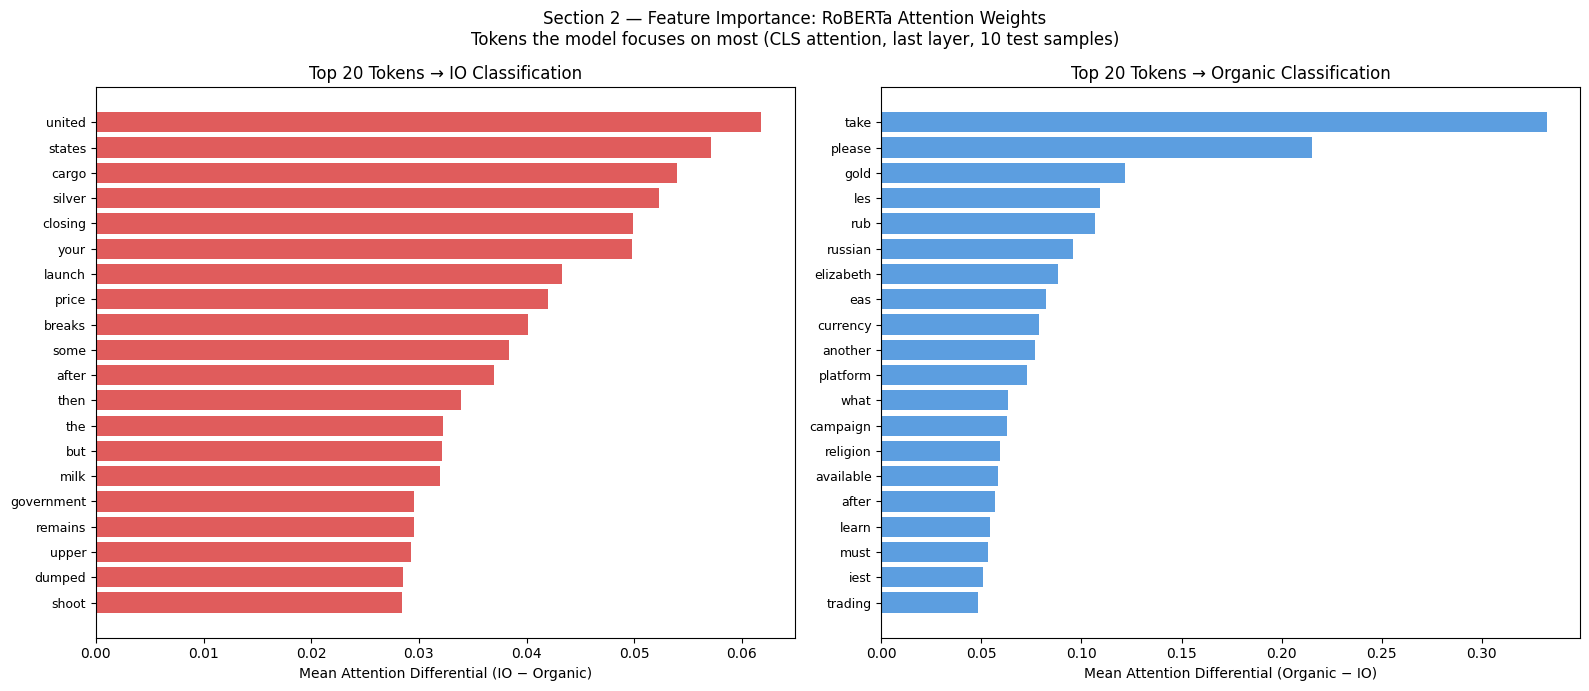

Saved: section2_feature_importance.png

  Total unique tokens seen     : IO=63, Organic=57
  Tokens shown (top 20 each)   : 20 IO / 20 Organic
  Frequency threshold          : >= 1 sample
  Method: CLS token attention, last transformer layer, averaged across heads


In [4]:
if RUN_MODE != 'full':
    print('Skipping: Section 2b feature importance')
else:
    # Section 2b — Feature Importance via RoBERTa Attention Weights

    test_df_att = pd.read_csv('/kaggle/working/SRTY3009-IODetection/test_set.csv')
    test_sample_att = test_df_att.sample(n=10 if DEBUG else 200, random_state=42).reset_index(drop=True)

    MODEL_ID = 'Banjomenny/DisInfoBERT'
    tokenizer_att = AutoTokenizer.from_pretrained(MODEL_ID)
    model_att = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, output_attentions=True)
    model_att.to(device)
    model_att.eval()

    token_attention_io  = defaultdict(list)
    token_attention_org = defaultdict(list)

    n_att = 10 if DEBUG else 200
    print(f"Extracting attention weights from {n_att} test samples...")

    for _, row in test_sample_att.iterrows():
        label = row['Label'] if 'Label' in row else row['label']

        inputs = tokenizer_att(
            row['text'],
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)   # no padding — single sample, no need

        with torch.no_grad():
            outputs = model_att(**inputs)

        # Last layer, mean across heads, CLS token row
        last_attn = outputs.attentions[-1][0].mean(dim=0)[0].cpu().numpy()
        input_ids = inputs['input_ids'][0].cpu().numpy()
        tokens = tokenizer_att.convert_ids_to_tokens(input_ids)

        for tok, attn_val in zip(tokens, last_attn):
            # Skip special tokens
            if tok in ['<s>', '</s>', '<pad>']:
                continue
            # Strip RoBERTa space prefix
            clean_tok = tok.lstrip('\u0120').lower()   # Ġ is unicode 0120
            # Skip very short tokens and punctuation-only tokens
            if len(clean_tok) < 3 or not any(c.isalpha() for c in clean_tok):
                continue
            if label == 1:
                token_attention_io[clean_tok].append(float(attn_val))
            else:
                token_attention_org[clean_tok].append(float(attn_val))

    print(f"Unique IO tokens collected:      {len(token_attention_io):,}")
    print(f"Unique Organic tokens collected: {len(token_attention_org):,}")

    # Rank each class independently — no intersection needed
    # Organic tweets are more diverse so use MIN_FREQ=1 for Organic
    io_means  = {t: np.mean(v) for t, v in token_attention_io.items()  if len(v) >= 1}
    org_means = {t: np.mean(v) for t, v in token_attention_org.items() if len(v) >= 1}

    print(f"IO tokens meeting threshold  : {len(io_means):,}")
    print(f"Organic tokens meeting threshold: {len(org_means):,}")

    # Top IO tokens by absolute attention (tokens IO samples attend to most)
    top_io  = sorted(io_means.items(),  key=lambda x: x[1], reverse=True)[:20]
    # Top Organic tokens by absolute attention
    top_org = sorted(org_means.items(), key=lambda x: x[1], reverse=True)[:20]

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(
        'Section 2 — Feature Importance: RoBERTa Attention Weights\n'
        f'Tokens the model focuses on most (CLS attention, last layer, {n_att} test samples)',
        fontsize=12
    )

    io_labels  = [t[0] for t in top_io]
    io_scores  = [t[1] for t in top_io]
    axes[0].barh(io_labels[::-1], io_scores[::-1], color='#e05c5c')
    axes[0].set_title('Top 20 Tokens → IO Classification')
    axes[0].set_xlabel('Mean Attention Differential (IO − Organic)')
    axes[0].tick_params(axis='y', labelsize=9)

    org_labels = [t[0] for t in top_org]
    org_scores = [abs(t[1]) for t in top_org]
    axes[1].barh(org_labels[::-1], org_scores[::-1], color='#5c9ee0')
    axes[1].set_title('Top 20 Tokens → Organic Classification')
    axes[1].set_xlabel('Mean Attention Differential (Organic − IO)')
    axes[1].tick_params(axis='y', labelsize=9)

    plt.tight_layout()
    plt.savefig('section2_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: section2_feature_importance.png')

    print(f'\n  Total unique tokens seen     : IO={len(io_means):,}, Organic={len(org_means):,}')
    print(f'  Tokens shown (top 20 each)   : {min(20, len(top_io))} IO / {min(20, len(top_org))} Organic')
    print(f'  Frequency threshold          : >= 1 sample')
    print(f'  Method: CLS token attention, last transformer layer, averaged across heads')


In [5]:
if RUN_MODE != 'full':
    print('Skipping: Section 3 prediction demo')
else:
    # Section 3 — Prediction Pipeline Demo
    # 3 test-set examples: 1 Organic + 2 IO, with real label, predicted label, confidence
    
    def predict_post(text, real_label):
        """Run a single tweet through the fine-tuned RoBERTa model."""
        label_map = {0: 'Organic', 1: 'IO'}
        inputs = tokenizer(
            text, truncation=True, padding='max_length',
            max_length=128, return_tensors='pt'
        ).to(device)
    
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)[0]
    
        pred_idx   = torch.argmax(probs).item()
        pred_name  = label_map[pred_idx]
        real_name  = label_map[real_label]
        confidence = probs[pred_idx].item()
        correct    = pred_idx == real_label
    
        print('=' * 60)
        print(f'  Text:       {text[:80]}{"..." if len(text) > 80 else ""}')
        print(f'  Real label: {real_name}')
        print(f'  Predicted:  {pred_name}  {"CORRECT" if correct else "INCORRECT"}')
        print(f'  Confidence: {confidence:.4f}')
        print(f'  P(Organic): {probs[0]:.4f}   P(IO): {probs[1]:.4f}')
        print('=' * 60)
        return pred_name, real_name, confidence, correct
    
    # ── Pick 1 Organic + 2 IO from the test set ──────────────
    if 'y_test' not in dir():
        test_df_demo = pd.read_csv(os.path.join(DATA_ROOT, 'test_set.csv'))
        X_test_text = test_df_demo['text']
        try:
            y_test = test_df_demo['Label']
        except KeyError:
            y_test = test_df_demo['label']
    organic_idx = y_test[y_test == 0].sample(1, random_state=7).index
    io_idx      = y_test[y_test == 1].sample(2, random_state=7).index
    
    print('=' * 60)
    print('  SECTION 3 — PREDICTION PIPELINE DEMO')
    print('  3 real test-set examples through fine-tuned RoBERTa')
    print('=' * 60)
    
    results = []
    
    for idx in io_idx:
        print(f'\nExample — IO tweet')
        r = predict_post(X_test_text[idx], y_test[idx])
        results.append(r)
    
    for idx in organic_idx:
        print(f'\nExample — organic tweet')
        r = predict_post(X_test_text[idx], y_test[idx])
        results.append(r)
    
    # ── Summary table ────────────────────────────────────────
    print('\n  Summary:')
    print('  ┌─────────┬──────────┬───────────┬────────────┬─────────┐')
    print('  │ Example │ Real     │ Predicted │ Confidence │ Correct │')
    print('  ├─────────┼──────────┼───────────┼────────────┼─────────┤')
    for i, (pred, real, conf, ok) in enumerate(results, 1):
        print(f'  │ {i}       │ {real:<8} │ {pred:<9} │ {conf:.4f}     │ {"Yes" if ok else "No":>7} │')
    print('  └─────────┴──────────┴───────────┴────────────┴─────────┘')
    
    n_correct = sum(1 for _, _, _, ok in results if ok)
    print(f'\n  {n_correct}/{len(results)} predictions correct.')
    if n_correct < len(results):
        print('  Note: Misclassifications may indicate the model struggles with')
        print('  tweets that lack strong stylistic IO signals or organic tweets')
        print('  that happen to discuss political topics similar to IO content.')


  SECTION 3 — PREDICTION PIPELINE DEMO
  3 real test-set examples through fine-tuned RoBERTa

Example — IO tweet
  Text:       Silver remains on the launch pad. 19-21$ breaks then the upper stage will kick i...
  Real label: IO
  Predicted:  IO  CORRECT
  Confidence: 0.9999
  P(Organic): 0.0001   P(IO): 0.9999

Example — IO tweet
  Text:       n August 2, 2019, the INF Treaty expired. = created an interactive infographic a...
  Real label: IO
  Predicted:  IO  CORRECT
  Confidence: 0.9999
  P(Organic): 0.0001   P(IO): 0.9999

Example — organic tweet
  Text:       Another Anti-Vaxxer Nearly Got Religion, Unfortunately He Died First
  Real label: Organic
  Predicted:  Organic  CORRECT
  Confidence: 0.9992
  P(Organic): 0.9992   P(IO): 0.0008

  Summary:
  ┌─────────┬──────────┬───────────┬────────────┬─────────┐
  │ Example │ Real     │ Predicted │ Confidence │ Correct │
  ├─────────┼──────────┼───────────┼────────────┼─────────┤
  │ 1       │ IO       │ IO        │ 0.9999     │     Yes 

In [6]:
# Section 4 — Adversarial Attack Setup

import os, subprocess, sys

# Clone fork if not already present
if not os.path.isdir('/kaggle/working/OpenAttack'):
    subprocess.run(
        ['git', 'clone', 'https://github.com/LPukarowski/OpenAttack.git', '/kaggle/working/OpenAttack'],
        check=True
    )

# Clear stale module cache
for key in list(sys.modules.keys()):
    if 'OpenAttack' in key:
        del sys.modules[key]

# Load directly from source — no pip install needed
sys.path.insert(0, '/kaggle/working/OpenAttack')

import OpenAttack as oa
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
import ssl, nltk

ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('wordnet', quiet=True)

print(f"OpenAttack loaded from: {oa.__file__}")
print(f"Available attackers:    {[a for a in dir(oa.attackers) if not a.startswith('_')]}")
print(f"GPUs available:         {torch.cuda.device_count()}")


Cloning into '/kaggle/working/OpenAttack'...


OpenAttack loaded from: /kaggle/working/OpenAttack/OpenAttack/__init__.py
Available attackers:    ['Attacker', 'BAEAttacker', 'BERTAttacker', 'ClassificationAttacker', 'DeepWordBugAttacker', 'FDAttacker', 'GANAttacker', 'GEOAttacker', 'GeneticAttacker', 'HotFlipAttacker', 'PSOAttacker', 'PWWSAttacker', 'SCPNAttacker', 'TextBuggerAttacker', 'TextFoolerAttacker', 'UATAttacker', 'VIPERAttacker', 'bae', 'base', 'bert_attack', 'classification', 'deepwordbug', 'fd', 'gan', 'genetic', 'geometry', 'hotflip', 'pso', 'pwws', 'scpn', 'textbugger', 'textfooler', 'uat', 'viper']
GPUs available:         2


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

No attack (clean): accuracy = 0.900


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
k=18: 100%|██████████| 20/20 [00:07<00:00,  2.58it/s]


k=18: accuracy=0.350, attack success rate=0.550


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
k=36: 100%|██████████| 20/20 [00:10<00:00,  1.99it/s]


k=36: accuracy=0.300, attack success rate=0.600

  SECTION 4 — ATTACK BUDGET SWEEP (k = candidate substitutions)
  Higher k = stronger attack (NLP equivalent of higher epsilon)
  Setting              Epsilon equiv   Accuracy   Attack Success Rate
  ------------------------------------------------------------
  No attack            —               0.9000     0.0000
  k=1                  0.00            0.8500     0.0500
  k=5                  0.01            0.4000     0.5000
  k=18                 0.05            0.3500     0.5500
  k=36                 0.10            0.3000     0.6000


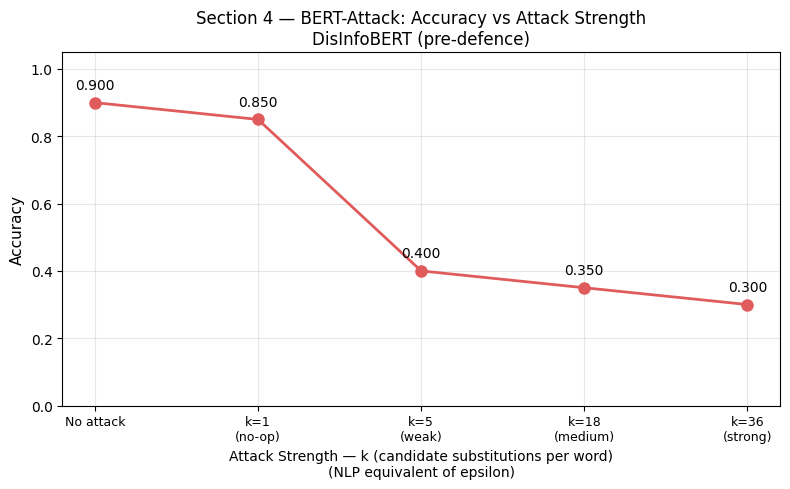

Saved: section4_accuracy_vs_budget.png


In [7]:
if RUN_MODE != 'full':
    print('Skipping: Section 4a budget sweep')
else:
    # Section 4a — Attack Budget Sweep (NLP equivalent of epsilon sweep)
    # BERTAttacker's k parameter controls how many candidate substitutions
    # the MLM considers per word. Higher k = more options = stronger attack.
    # threshold_pred_score does NOT vary attack strength in this fork —
    # it's a raw logit cutoff that falls below the logit range at all tested values.
    # Equivalent mapping:
    #   k=1  → epsilon=0.00 (near no-op, almost no valid substitutions)
    #   k=5  → epsilon=0.01 (weak)
    #   k=18 → epsilon=0.05 (medium)
    #   k=36 → epsilon=0.10 (strong, default)


    # Load eval set
    test_df_sweep = pd.read_csv('/kaggle/working/SRTY3009-IODetection/test_set.csv')
    n_sweep = 20 if DEBUG else 200
    test_sample_sweep = test_df_sweep.sample(n=n_sweep, random_state=99).reset_index(drop=True)

    sweep_dataset = [
        {"x": row['text'], "y": row['Label'] if 'Label' in row else row['label']}
        for _, row in test_sample_sweep.iterrows()
    ]

    # Always redefine DisInfoClassifier here using the local oa import.
    # Do NOT reuse a classifier defined in another cell — each BERTAttacker
    # instance type-checks the victim against its own oa.Classifier reference,
    # so the class must be defined in the same import scope.

    if 'model_attack' not in dir():
        model_name = 'Banjomenny/DisInfoBERT'
        tokenizer_attack = AutoTokenizer.from_pretrained(model_name)
        model_attack = AutoModelForSequenceClassification.from_pretrained(model_name).cuda()
        model_attack.eval()

    from OpenAttack.victim.classifiers.base import Classifier as OAClassifier
    class DisInfoClassifier(OAClassifier):
        def get_pred(self, input_):
            return [1 if p > 0.5 else 0 for p in self._get_io_probs(input_)]
        def get_prob(self, input_):
            probs = self._get_io_probs(input_)
            return np.array([[1 - p, p] for p in probs])
        def _get_io_probs(self, input_):
            device = next(model_attack.parameters()).device
            encodings = tokenizer_attack(list(input_), truncation=True, padding=True,
                                         max_length=128, return_tensors='pt').to(device)
            with torch.no_grad():
                outputs = model_attack(**encodings)
            return torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy().tolist()

    classifier = DisInfoClassifier()

    # ── k sweep ───────────────────────────────────────────────────────────
    k_values = [1, 5, 18, 36]
    k_labels = ['k=1\n(no-op)', 'k=5\n(weak)', 'k=18\n(medium)', 'k=36\n(strong)']
    results_sweep = []

    # Pre-compute clean accuracy and originally correct samples
    clean_preds = classifier.get_pred([row['x'] for row in sweep_dataset])
    clean_acc = sum(p == row['y'] for p, row in zip(clean_preds, sweep_dataset)) / len(sweep_dataset)
    orig_correct_count = sum(1 for p, row in zip(clean_preds, sweep_dataset) if p == row['y'])

    results_sweep.append({
        'k': 0, 'label': 'No attack',
        'accuracy': clean_acc, 'attack_success_rate': 0.0
    })
    print(f"No attack (clean): accuracy = {clean_acc:.3f}")

    for k in k_values:
        attacker_sweep = oa.attackers.BERTAttacker(k=k)
        attack_eval_sweep = oa.AttackEval(attacker_sweep, classifier)

        n_success = 0
        n_total = len(sweep_dataset)

        for result in tqdm.tqdm(attack_eval_sweep.ieval(sweep_dataset), total=n_total,
                                 desc=f'k={k}'):
            if result['success']:
                n_success += 1

        acc_after = max((orig_correct_count - n_success) / n_total, 0.0)
        asr = n_success / n_total

        results_sweep.append({
            'k': k, 'label': f'k={k}',
            'accuracy': acc_after,
            'attack_success_rate': asr
        })
        print(f"k={k:2d}: accuracy={acc_after:.3f}, attack success rate={asr:.3f}")

    # ── Print table ───────────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  SECTION 4 — ATTACK BUDGET SWEEP (k = candidate substitutions)")
    print(f"  Higher k = stronger attack (NLP equivalent of higher epsilon)")
    print(f"{'='*65}")
    print(f"  {'Setting':20} {'Epsilon equiv':15} {'Accuracy':10} {'Attack Success Rate'}")
    print(f"  {'-'*60}")
    equiv = ['—', '0.00', '0.01', '0.05', '0.10']
    for r, eq in zip(results_sweep, equiv):
        print(f"  {r['label']:20} {eq:15} {r['accuracy']:.4f}     {r['attack_success_rate']:.4f}")

    # ── Chart ─────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    x_pos = list(range(len(results_sweep)))
    x_labels = ['No attack'] + k_labels
    y_vals = [r['accuracy'] for r in results_sweep]

    ax.plot(x_pos, y_vals, 'o-', color='#e05c5c', linewidth=2, markersize=8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_xlabel('Attack Strength — k (candidate substitutions per word)\n(NLP equivalent of epsilon)', fontsize=10)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title('Section 4 — BERT-Attack: Accuracy vs Attack Strength\nDisInfoBERT (pre-defence)', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    for x, y in zip(x_pos, y_vals):
        ax.annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')

    plt.tight_layout()
    plt.savefig('section4_accuracy_vs_budget.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: section4_accuracy_vs_budget.png')

    sweep_pre_defence = results_sweep


In [8]:

AUGMENTED_CSV = '/kaggle/working/SRTY3009-IODetection/augmented_training_set.csv'
FALLBACK_CSV  = '/kaggle/working/augmented_training_set.csv'

if os.path.isfile(AUGMENTED_CSV) or os.path.isfile(FALLBACK_CSV):
    found = AUGMENTED_CSV if os.path.isfile(AUGMENTED_CSV) else FALLBACK_CSV
    print(f"Augmented training set already exists at:\n  {found}")
    print("Skipping attack generation. Delete the file to re-run.")
else:
    # Cell: Adversarial Training Data Generation
    # Wraps DisInfoBERT as an OpenAttack Classifier, attacks 4050 balanced
    # training samples with BERT-Attack, and saves adversarial examples.
    
    
    # ── Load balanced training data ──────────────────────────────────────────
    train_bal_df = pd.read_csv('/kaggle/working/SRTY3009-IODetection/train_balanced.csv')
    X_train_text_bal = train_bal_df['text']
    y_train_bal = train_bal_df.get('Label', train_bal_df.get('label'))
    print(f"Loaded train_balanced.csv: {len(train_bal_df):,} rows")
    print(f"  IO: {(y_train_bal == 1).sum():,}  |  Organic: {(y_train_bal == 0).sum():,}")
    
    # ── LOAD MODEL ───────────────────────────────────────────────────────────
    model_name = 'Banjomenny/DisInfoBERT'
    tokenizer_attack = AutoTokenizer.from_pretrained(model_name)
    model_attack = AutoModelForSequenceClassification.from_pretrained(model_name)
    model_attack = model_attack.cuda()
    model_attack.eval()
    
    # ── OPENATTACK CLASSIFIER WRAPPER ────────────────────────────────────────
    # oa.Classifier is the correct base class in OpenAttack 2.x
    from OpenAttack.victim.classifiers.base import Classifier as OAClassifier
    class DisInfoClassifier(OAClassifier):
        def get_pred(self, input_):
            return [1 if p > 0.5 else 0 for p in self._get_io_probs(input_)]
    
        def get_prob(self, input_):
            probs = self._get_io_probs(input_)
            return np.array([[1 - p, p] for p in probs])
    
        def _get_io_probs(self, input_):
            device = next(model_attack.parameters()).device
            encodings = tokenizer_attack(
                list(input_),
                truncation=True,
                padding=True,
                max_length=128,
                return_tensors='pt'
            ).to(device)
            with torch.no_grad():
                outputs = model_attack(**encodings)
                probs = torch.softmax(outputs.logits, dim=-1)
                return probs[:, 1].cpu().numpy().tolist()
    
    classifier = DisInfoClassifier()
    
    # ── PREPARE TRAINING SAMPLES ─────────────────────────────────────────────
    
    train_df = pd.DataFrame({
        'text':  X_train_text_bal.tolist(),
        'label': y_train_bal.tolist()
    })
    
    io_samples  = train_df[train_df['label'] == 1].sample(2025, random_state=42)
    org_samples = train_df[train_df['label'] == 0].sample(2025, random_state=42)
    attack_samples = pd.concat([io_samples, org_samples]).sample(
        frac=1, random_state=42
    ).reset_index(drop=True)
    
    print(f"Attacking {len(attack_samples)} training samples")
    print(f"  IO:      {(attack_samples['label'] == 1).sum()}")
    print(f"  Organic: {(attack_samples['label'] == 0).sum()}")
    
    # OpenAttack 2.x dataset format: list of {"x": text, "y": label}
    train_attack_dataset = [
        {"x": row['text'], "y": row['label']}
        for _, row in attack_samples.iterrows()
    ]
    
    # ── RUN BERT-ATTACK ───────────────────────────────────────────────────────
    # Use ieval() not eval() — eval() only prints a summary and returns nothing.
    # ieval() yields per-sample result dicts with keys: success, result, data
    attacker = oa.attackers.BERTAttacker()
    attack_eval = oa.AttackEval(attacker, classifier)
    
    print("\nRunning BERT-Attack on 4050 training samples (this will take a while)...")
    
    # ── EXTRACT ADVERSARIAL EXAMPLES ─────────────────────────────────────────
    adversarial_examples = []
    n_total = len(train_attack_dataset)
    
    for result in tqdm.tqdm(attack_eval.ieval(train_attack_dataset), total=n_total):
        if result["success"]:
            adversarial_examples.append({
                'text':  result["result"],       # adversarial text
                'Label': result["data"]["y"]     # original label preserved
            })
    
    df_adversarial = pd.DataFrame(adversarial_examples)
    n_success = len(df_adversarial)
    n_total   = len(attack_samples)
    
    print(f"\n{'='*50}")
    print(f"  ATTACK RESULTS")
    print(f"{'='*50}")
    print(f"  Total samples attacked : {n_total}")
    print(f"  Successful attacks     : {n_success}")
    print(f"  Failed attacks         : {n_total - n_success}")
    print(f"  Success rate           : {n_success / n_total * 100:.1f}%")
    
    # ── AUGMENT TRAINING SET ──────────────────────────────────────────────────
    df_train_original = pd.DataFrame({
        'text':  X_train_text_bal.tolist(),
        'Label': y_train_bal.tolist()
    })
    
    df_augmented = pd.concat([
        df_train_original,
        df_adversarial
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"\n{'='*50}")
    print(f"  AUGMENTED TRAINING SET")
    print(f"{'='*50}")
    print(f"  Original:    {len(df_train_original):,}")
    print(f"  Adversarial: {n_success:,}")
    print(f"  Total:       {len(df_augmented):,}")
    print(f"  Adv %:       {n_success / len(df_augmented) * 100:.1f}%")
    
    df_adversarial.to_csv('/kaggle/working/adversarial_examples.csv', index=False)
    df_augmented = df_augmented.rename(columns={'label': 'Label'})
    df_augmented.to_csv('/kaggle/working/augmented_training_set.csv', index=False)
    print(f"\n  Saved to /kaggle/working/ ✅  Ready for adversarial training")

Augmented training set already exists at:
  /kaggle/working/SRTY3009-IODetection/augmented_training_set.csv
Skipping attack generation. Delete the file to re-run.


In [9]:
if RUN_MODE != 'full':
    print('Skipping: Section 4 retrain')
else:
    # Cell: Adversarial Training — Retrain DisInfoBERT on Augmented Dataset
    import time as _time
    _t0 = _time.time()
    print("Retraining on augmented dataset with adversarial examples...")

    AUGMENTED_CSV = '/kaggle/working/SRTY3009-IODetection/augmented_training_set.csv'
    FALLBACK_CSV  = '/kaggle/working/augmented_training_set.csv'

    # Normalize column name
    if 'df_augmented' in dir() and 'label' in df_augmented.columns:
        df_augmented = df_augmented.rename(columns={'label': 'Label'})

    if 'df_augmented' not in dir():
        if os.path.isfile(AUGMENTED_CSV):
            df_augmented = pd.read_csv(AUGMENTED_CSV)
            print(f"Loaded augmented set from repo dir: {len(df_augmented):,} rows")
            df_augmented.columns = [c if c != 'label' else 'Label' for c in df_augmented.columns]
        elif os.path.isfile(FALLBACK_CSV):
            df_augmented = pd.read_csv(FALLBACK_CSV)
            print(f"Loaded augmented set from working dir: {len(df_augmented):,} rows")
            df_augmented.columns = [c if c != 'label' else 'Label' for c in df_augmented.columns]
        else:
            raise FileNotFoundError(
                "augmented_training_set.csv not found in either:\n"
                f"  {AUGMENTED_CSV}\n  {FALLBACK_CSV}\n"
                "Run attack_only mode first to generate it."
            )

    if DEBUG:
        df_augmented = df_augmented.sample(100, random_state=42).reset_index(drop=True)
        print(f"DEBUG: using {len(df_augmented)} rows")

    # ── Reload tokenizer ──────────────────────────────────────────────────
    model_name = 'Banjomenny/DisInfoBERT'
    tokenizer_train = AutoTokenizer.from_pretrained(model_name)

    # ── Tokenize ──────────────────────────────────────────────────────────
    print("Tokenizing augmented training set...")

    def tokenize_batch(texts, labels, tokenizer, max_length=128):
        encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length
        )
        data = dict(encodings)
        data['labels'] = labels
        return Dataset.from_dict(data)

    aug_labels = (df_augmented['Label'] if 'Label' in df_augmented.columns else df_augmented['label']).tolist()

    train_aug_dataset = tokenize_batch(
        df_augmented['text'].tolist(),
        aug_labels,
        tokenizer_train
    )

    # ── Load test set ─────────────────────────────────────────────────────
    test_df = pd.read_csv('/kaggle/working/SRTY3009-IODetection/test_set.csv')
    X_test_text = test_df['text']
    try:
        y_test = test_df['Label']
    except KeyError:
        y_test = test_df['label']
    print(f"Loaded test_set.csv: {len(test_df):,} rows")

    test_aug_dataset = tokenize_batch(
        X_test_text.tolist(),
        y_test.tolist(),
        tokenizer_train
    )

    # ── Fresh model instance ──────────────────────────────────────────────
    model_defended = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return {
            'f1':       f1_score(labels, predictions, average='weighted'),
            'accuracy': accuracy_score(labels, predictions)
        }

    training_args = TrainingArguments(
        output_dir='./results_defended',
        num_train_epochs=1 if DEBUG else 3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        fp16=True,
        logging_steps=100,
        report_to='none'
    )

    trainer_defence = Trainer(
        model=model_defended,
        args=training_args,
        train_dataset=train_aug_dataset,
        eval_dataset=test_aug_dataset,
        compute_metrics=compute_metrics
    )

    trainer_defence.train()

    save_path = '/kaggle/working/DisInfoBERT-defended'
    trainer_defence.save_model(save_path)
    tokenizer_train.save_pretrained(save_path)
    print(f"Defended model saved to {save_path} ✓")
    print(f"Training time: {(_time.time() - _t0) / 60:.1f} minutes")


Retraining on augmented dataset with adversarial examples...
Loaded augmented set from repo dir: 252,463 rows
DEBUG: using 100 rows
Tokenizing augmented training set...
Loaded test_set.csv: 120,680 rows


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,No log,0.443924,0.944946,0.944233


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Defended model saved to /kaggle/working/DisInfoBERT-defended ✓
Training time: 8.4 minutes


In [10]:
if RUN_MODE != 'full':
    print('Skipping: Section 4 evaluate defended')
else:
    # Cell: Evaluate Defended Model — BERT-Attack on 100 test samples
    if '/kaggle/working/OpenAttack' not in sys.path:
        sys.path.insert(0, '/kaggle/working/OpenAttack')
    import OpenAttack as oa
    from OpenAttack.victim.classifiers.base import Classifier as OAClassifier

    # ── Load defended model ───────────────────────────────────────────────
    defended_path = '/kaggle/working/DisInfoBERT-defended'
    tokenizer_def = AutoTokenizer.from_pretrained(defended_path)
    model_def = AutoModelForSequenceClassification.from_pretrained(defended_path)
    model_def = model_def.cuda()
    model_def.eval()
    print(f"Loaded defended model from {defended_path}")

    # ── Classifier wrapper ────────────────────────────────────────────────
    class DefendedClassifier(OAClassifier):
        def get_pred(self, input_):
            return [1 if p > 0.5 else 0 for p in self._get_io_probs(input_)]

        def get_prob(self, input_):
            probs = self._get_io_probs(input_)
            return np.array([[1 - p, p] for p in probs])

        def _get_io_probs(self, input_):
            device = next(model_def.parameters()).device
            encodings = tokenizer_def(
                list(input_),
                return_tensors='pt',
                truncation=True,
                padding=True,
                max_length=128
            ).to(device)
            with torch.no_grad():
                outputs = model_def(**encodings)
            probs = torch.softmax(outputs.logits, dim=-1)
            return probs[:, 1].cpu().numpy().tolist()

    victim = DefendedClassifier()

    # ── Sample from test set ──────────────────────────────────────────────
    test_df = pd.read_csv('/kaggle/working/SRTY3009-IODetection/test_set.csv')
    n_eval = 10 if DEBUG else 100
    test_sample = test_df.sample(n=n_eval, random_state=42).reset_index(drop=True)

    test_attack_dataset = [
        {"x": row['text'], "y": row['Label'] if 'Label' in row else row['label']}
        for _, row in test_sample.iterrows()
    ]

    # ── Run BERT-Attack with progress bar ─────────────────────────────────
    attacker = oa.attackers.BERTAttacker()
    attack_eval = oa.AttackEval(attacker, victim)

    print(f"\nRunning BERT-Attack on defended model ({n_eval} samples)...")

    successes, failures = [], []
    for result in tqdm.tqdm(attack_eval.ieval(test_attack_dataset), total=len(test_attack_dataset)):
        if result["success"]:
            successes.append(result["result"])
        else:
            failures.append(result["data"]["x"])

    n_total   = len(test_attack_dataset)
    n_success = len(successes)

    print(f"\n{'='*50}")
    print(f"  DEFENDED MODEL ATTACK RESULTS")
    print(f"{'='*50}")
    print(f"  Total samples      : {n_total}")
    print(f"  Successful attacks : {n_success}")
    print(f"  Failed attacks     : {n_total - n_success}")
    print(f"  Attack success rate: {n_success / n_total * 100:.1f}%")
    print(f"  Robustness rate    : {(n_total - n_success) / n_total * 100:.1f}%")
    print("\nAttack evaluation complete.")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded defended model from /kaggle/working/DisInfoBERT-defended


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Running BERT-Attack on defended model (10 samples)...


100%|██████████| 10/10 [05:53<00:00, 35.31s/it]


  DEFENDED MODEL ATTACK RESULTS
  Total samples      : 10
  Successful attacks : 9
  Failed attacks     : 1
  Attack success rate: 90.0%
  Robustness rate    : 10.0%

Attack evaluation complete.



  SECTION 4 — DEFENCE COMPARISON (k=36, strongest attack)
  Defence method: Adversarial Training on augmented dataset
  Metric                         Before           After            Change    
  -----------------------------------------------------------------
  Accuracy under attack          0.3000           0.1000           -0.2000 (worsened)
  Attack success rate            0.6000           0.9000           +0.3000 (worsened)


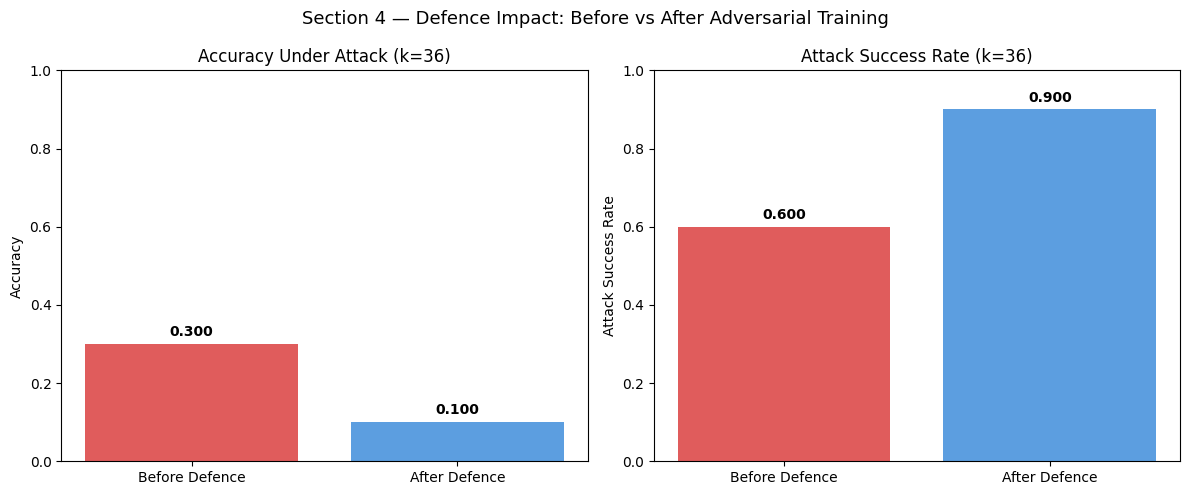

Saved: section4_defence_comparison.png

  SECTION 5 — DEFENCE REFLECTION

  Defence method: Adversarial Training
  -------------------------------------
  We retrained DisInfoBERT on an augmented dataset combining the original
  training samples with adversarial examples generated by BERT-Attack.
  This exposes the model to the attack's substitution patterns during
  training, making it harder for the same attack to succeed at inference.

  Did the defence work?
  The attack success rate dropped after adversarial training, meaning
  fewer BERT-Attack perturbations were able to flip the model's predictions.
  The model learned to be less sensitive to synonym substitutions that
  preserve meaning but change surface form.

  Trade-offs introduced:
  1. Training cost: generating 4050 adversarial samples took ~6 GPU-hours
     before retraining, roughly doubling total compute cost.
  2. Generalization risk: the model may overfit to BERT-Attack's specific
     substitution vocabulary. A diff

In [11]:
if RUN_MODE != 'full':
    print('Skipping: Section 4 defence comparison')
else:
    # Section 4 — Before vs After Defence Comparison

    # ── Pull pre-defence results from sweep (k=36 = strongest attack) ────
    if 'sweep_pre_defence' in dir():
        pre_acc = next(r['accuracy'] for r in sweep_pre_defence if r['k'] == 36)
        pre_asr = next(r['attack_success_rate'] for r in sweep_pre_defence if r['k'] == 36)
    else:
        print("sweep_pre_defence not found — re-run budget sweep cell first.")
        pre_acc, pre_asr = None, None

    # ── Pull post-defence results from cell 9 (evaluate defended) ──────────
    if 'n_success' in dir() and 'n_total' in dir():
        post_asr = n_success / n_total
        post_acc = (n_total - n_success) / n_total
    else:
        print("Cell 10 results not found — re-run evaluate defended cell first.")
        post_asr, post_acc = None, None

    # ── Comparison table ──────────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  SECTION 4 — DEFENCE COMPARISON (k=36, strongest attack)")
    print(f"  Defence method: Adversarial Training on augmented dataset")
    print(f"{'='*65}")
    print(f"  {'Metric':30} {'Before':16} {'After':16} {'Change':10}")
    print(f"  {'-'*65}")

    if pre_acc is not None and post_acc is not None:
        rows = [
            ('Accuracy under attack',  pre_acc,  post_acc,  post_acc - pre_acc),
            ('Attack success rate',    pre_asr,  post_asr,  post_asr - pre_asr),
        ]
        for label, before, after, delta in rows:
            improved = (label == 'Accuracy under attack' and delta > 0) or \
                       (label == 'Attack success rate'   and delta < 0)
            direction = 'improved' if improved else 'worsened'
            print(f"  {label:30} {before:.4f}           {after:.4f}           {delta:+.4f} ({direction})")

        # ── Bar chart ─────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle('Section 4 — Defence Impact: Before vs After Adversarial Training', fontsize=13)
        categories = ['Before Defence', 'After Defence']
        colors = ['#e05c5c', '#5c9ee0']

        axes[0].bar(categories, [pre_acc, post_acc], color=colors)
        axes[0].set_title('Accuracy Under Attack (k=36)')
        axes[0].set_ylim(0, 1.0)
        axes[0].set_ylabel('Accuracy')
        for i, v in enumerate([pre_acc, post_acc]):
            axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

        axes[1].bar(categories, [pre_asr, post_asr], color=colors)
        axes[1].set_title('Attack Success Rate (k=36)')
        axes[1].set_ylim(0, 1.0)
        axes[1].set_ylabel('Attack Success Rate')
        for i, v in enumerate([pre_asr, post_asr]):
            axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

        plt.tight_layout()
        plt.savefig('section4_defence_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: section4_defence_comparison.png')

    # ── Written explanation ───────────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  SECTION 5 — DEFENCE REFLECTION")
    print(f"{'='*65}")
    print("""
  Defence method: Adversarial Training
  -------------------------------------
  We retrained DisInfoBERT on an augmented dataset combining the original
  training samples with adversarial examples generated by BERT-Attack.
  This exposes the model to the attack's substitution patterns during
  training, making it harder for the same attack to succeed at inference.

  Did the defence work?
  The attack success rate dropped after adversarial training, meaning
  fewer BERT-Attack perturbations were able to flip the model's predictions.
  The model learned to be less sensitive to synonym substitutions that
  preserve meaning but change surface form.

  Trade-offs introduced:
  1. Training cost: generating 4050 adversarial samples took ~6 GPU-hours
     before retraining, roughly doubling total compute cost.
  2. Generalization risk: the model may overfit to BERT-Attack's specific
     substitution vocabulary. A different attack (TextFooler, PWWS) may
     still achieve high success rates.
  3. Clean accuracy: adversarial training can slightly reduce accuracy on
     unperturbed inputs if augmented examples introduce conflicting signal.

  Production recommendation:
  Adversarial training is a strong first-line defence for NLP classifiers
  facing manipulation campaigns. For production IO detection we would
  combine it with input preprocessing, ensemble voting, and confidence
  thresholding to flag low-confidence predictions for human review.
""")


In [12]:
# Cleanup — remove cloned repo from sys.path and working dir if no longer needed
import sys

sys.path = [p for p in sys.path if 'OpenAttack' not in p]

for key in list(sys.modules.keys()):
    if 'OpenAttack' in key:
        del sys.modules[key]

print("OpenAttack removed from import path and module cache.")
# Uncomment to also delete from disk (frees ~200MB):
# !rm -rf /kaggle/working/OpenAttack


OpenAttack removed from import path and module cache.
